# Введение
## Цель
Изучение методов классификации данных, реализованные в библиотеке Scikit-Learn, а также ознакомление с нейронными сетями с использованием библиотек TensorFlow и TensorBoard. 
## Задачи
1. Необходимо выбрать и подготовить датасет для классификации, затем построить классификационные модели с помощью пяти методов:
    - Наивный Байесовский классификатор (GaussianNB, MultinomialNB, ComplementNB, BernoulliNB);
    - Деревья решений (Decision Tree);
    - Линейный дискриминантный анализ (Linear Discriminant Analysis);
    - Метод опорных векторов (Support Vector Machines);
    - Метод ближайших соседей (k-Nearest Neighbors);
2. Затем сравните качество работы классификаторов с помощью следующих метрик:
    - Accuracy (точность),
    - Precision (доля правильно классифицированных положительных примеров),
    - Recall (чувствительность, доля верно найденных положительных примеров),
    - F1-Score (среднее гармоническое precision и recall),
    - Площадь под кривой ROC (AUC-ROC).
3. Настройте гиперпараметры каждого метода и проведите исследование влияния различных параметров на качество классификации.
4. Реализуйте и протестируйте нейронную сеть на TensorFlow, исследуйте эффект настройки гиперпараметров и визуализируйте процесс обучения с помощью инструмента TensorBoard.

# Выбор и подготовка датасета
## Описание датасета
Для работы выбран датасет [Wine Quality Dataset](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset). 

Этот датасет содержит информацию о красных винах португальского региона "Винью Верде". Данные были собраны в результате физико-химических лабораторных тестов, а целевая переменная (качество) основана на сенсорной оценке (дегустации).
Признаки:
1. fixed acidity - титруемая кислотность
2. volatile acidity - летучая кислотность
3. citric acid - лимонная кислота
4. residual sugar - остаточный сахар
5. chlorides - хлориды
6. free sulfur dioxide - свободный диоксид серы
7. total sulfur dioxide - общий диоксид серы
8. density - плотность
9. pH - водородный показатель
10. sulphates - сульфаты
11. alcohol - алкоголь (в %)
12. quality - качество (от 0 до 10)

In [468]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sb
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler
import math
import scipy.stats as stats

file_path = "WineQT.csv"

df = kagglehub.dataset_load(
  kagglehub.KaggleDatasetAdapter.PANDAS,
  "yasserh/wine-quality-dataset",
  file_path,
)

df = df.drop(columns=["Id"]) # Убираю id записи, не понадобится
display(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Анализ параметров

,Признак,Среднее,Медиана,Мода,Минимум,Максимум,Стандартное отклонение,Дисперсия,Асимметрия,Эксцесс,"Квантили (25%, 50%, 75%)",Оценка нормальности распредления (тест Колмагорова-Смирнова)
0,Титруемая кислотность (fixed acidity),8.31,7.90,7.20,4.60,15.90,1.75,3.05,1.04,1.38,"{0.25: 7.1, 0.5: 7.9, 0.75: 9.1}",p=4.679e-12 → Далеко от нормального
1,Летучая кислотность (volatile acidity),0.53,0.52,0.50,0.12,1.58,0.18,0.03,0.68,1.38,"{0.25: 0.3925, 0.5: 0.52, 0.75: 0.64}",p=5.665e-03 → Далеко от нормального
2,Лимонная кислота (citric acid),0.27,0.25,0.00,0.00,1.00,0.20,0.04,0.37,-0.71,"{0.25: 0.09, 0.5: 0.25, 0.75: 0.42}",p=7.683e-08 → Далеко от нормального
3,Остаточный сахар (residual sugar),2.53,2.20,2.00,0.90,15.50,1.36,1.84,4.36,27.68,"{0.25: 1.9, 0.5: 2.2, 0.75: 2.6}",p=5.887e-68 → Далеко от нормального
4,Хлориды (chlorides),0.09,0.08,0.08,0.01,0.61,0.05,0.00,6.03,47.08,"{0.25: 0.07, 0.5: 0.079, 0.75: 0.09}",p=1.097e-67 → Далеко от нормального
5,Свободный диоксид серы (free sulfur dioxide),15.62,13.00,6.00,1.00,68.00,10.25,105.07,1.23,1.93,"{0.25: 7.0, 0.5: 13.0, 0.75: 21.0}",p=1.948e-12 → Далеко от нормального
6,Общий диоксид серы (total sulfur dioxide),45.91,37.00,28.00,6.00,289.00,32.78,1074.67,1.67,5.10,"{0.25: 21.0, 0.5: 37.0, 0.75: 61.0}",p=4.584e-15 → Далеко от нормального
7,Плотность (density),1.00,1.00,1.00,0.99,1.00,0.00,0.00,0.10,0.89,"{0.25: 0.99557, 0.5: 0.99668, 0.75: 0.997845}",p=2.312e-02 → Близко к нормальному
8,Водородный показатель (pH),3.31,3.31,3.30,2.74,4.01,0.16,0.02,0.22,0.93,"{0.25: 3.205, 0.5: 3.31, 0.75: 3.4}",p=1.425e-02 → Близко к нормальному
9,Сульфаты (sulphates),0.66,0.62,0.60,0.33,2.00,0.17,0.03,2.50,12.02,"{0.25: 0.55, 0.5: 0.62, 0.75: 0.73}",p=2.989e-17 → Далеко от нормального


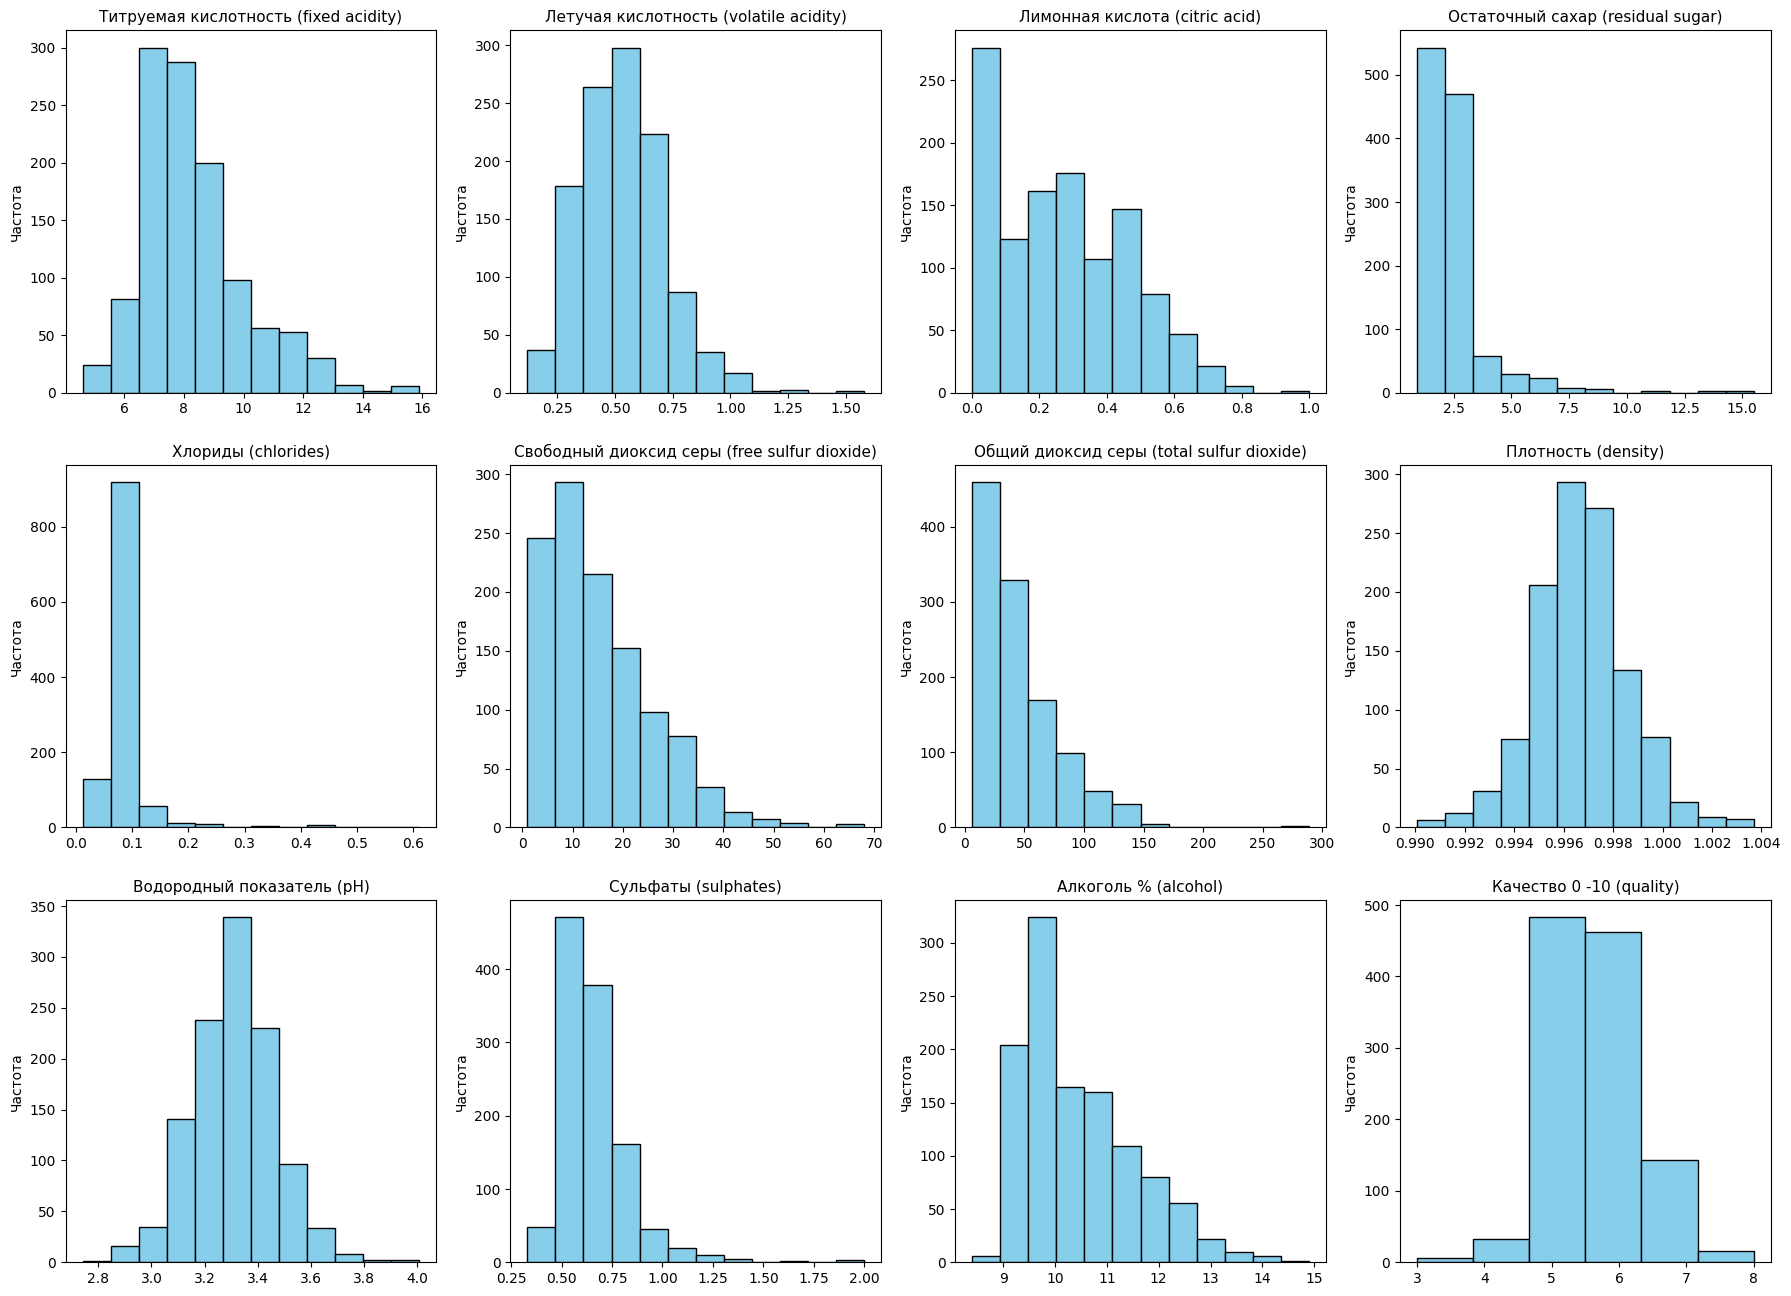

In [ ]:
n = df.shape[0]
k = int(math.ceil(1 + math.log2(n)))

translate = {
    "fixed acidity" : "Титруемая кислотность (fixed acidity)",
    "volatile acidity" : "Летучая кислотность (volatile acidity)",
    "citric acid" : "Лимонная кислота (citric acid)",
    "residual sugar" : "Остаточный сахар (residual sugar)",
    "chlorides" : "Хлориды (chlorides)",
    "free sulfur dioxide" : "Свободный диоксид серы (free sulfur dioxide)",
    "total sulfur dioxide" : "Общий диоксид серы (total sulfur dioxide)",
    "density" : "Плотность (density)",
    "pH" : "Водородный показатель (pH)",
    "sulphates" : "Сульфаты (sulphates)",
    "alcohol" : "Алкоголь % (alcohol)",
    "quality" : "Качество 0 -10 (quality)"
}

features = df.columns
fig, axes = plt.subplots(3, 4, figsize=(22, 16))
axes = axes.flatten()

stat = {
    "Признак": [], "Среднее": [], "Медиана": [], "Мода": [], "Минимум": [], "Максимум": [],
    "Стандартное отклонение": [], "Дисперсия": [], "Асимметрия": [], "Эксцесс": [], "Квантили (25%, 50%, 75%)": [],
    "Оценка нормальности распредления (тест Колмагорова-Смирнова)": []
    }

for i, feature in enumerate(features):
    ks_test = stats.kstest(df[feature], 'norm', args=(df[feature].mean(), df[feature].std()))

    # Собируем статистику
    stat["Признак"].append(translate[feature])
    stat["Среднее"].append(round(df[feature].mean(), 2))
    stat["Медиана"].append(round(df[feature].median(), 2))
    stat["Мода"].append(round(df[feature].mode()[0], 2))
    stat["Минимум"].append(round(df[feature].min(), 2))
    stat["Максимум"].append(round(df[feature].max(), 2))
    stat["Стандартное отклонение"].append(round(df[feature].std(), 2))
    stat["Дисперсия"].append(round(df[feature].var(), 2))
    stat["Асимметрия"].append(round(df[feature].skew(), 2))
    stat["Эксцесс"].append(round(df[feature].kurtosis(), 2))
    stat["Квантили (25%, 50%, 75%)"].append(df[feature].quantile([0.25, 0.5, 0.75]).to_dict())
    stat["Оценка нормальности распредления (тест Колмагорова-Смирнова)"].append(f"p={ks_test.pvalue:.3e} → {interpret_pvalue(ks_test.pvalue)}")


    # Строим гистограммы для всех признаков
    k_ = k if feature != "quality" else 6
    axes[i].hist(df[feature], bins=k_, edgecolor='black', color='skyblue')
    axes[i].set_title(translate[feature], fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Частота")

display(pd.DataFrame(stat))

Отсюда видна большая проблема - у quality очень маленькая частота для 3. Поменяем качество 3 -> 4, а так же приведем к 5-бальной шкале (от 1 до 5).

,Признак,Среднее,Медиана,Мода,Минимум,Максимум,Стандартное отклонение,Дисперсия,Асимметрия,Эксцесс,"Квантили (25%, 50%, 75%)",Оценка нормальности распредления (тест Колмагорова-Смирнова)
0,Качество 1-5 (quality),2.66,3.0,2,1,5,0.79,0.63,0.43,-0.02,"{0.25: 2.0, 0.5: 3.0, 0.75: 3.0}",p=3.651e-66 → Далеко от нормального


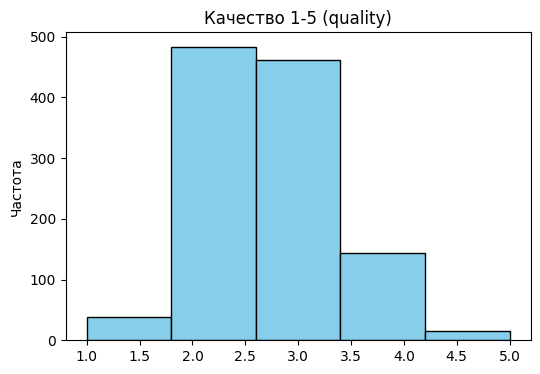

In [470]:
y = df['quality'].map({3: 1, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5})
df['quality'] = y

translate['quality'] = "Качество 1-5 (quality)"
feature = 'quality'
ks_test = stats.kstest(df[feature], 'norm', args=(df[feature].mean(), df[feature].std()))

stat = {
    "Признак": translate[feature],
    "Среднее": round(df[feature].mean(), 2),
    "Медиана": round(df[feature].median(), 2),
    "Мода": round(df[feature].mode()[0], 2),
    "Минимум": round(df[feature].min(), 2),
    "Максимум": round(df[feature].max(), 2),
    "Стандартное отклонение": round(df[feature].std(), 2),
    "Дисперсия": round(df[feature].var(), 2),
    "Асимметрия": round(df[feature].skew(), 2),
    "Эксцесс": round(df[feature].kurtosis(), 2),
    "Квантили (25%, 50%, 75%)": df[feature].quantile([0.25, 0.5, 0.75]).to_dict(),
    "Оценка нормальности распредления (тест Колмагорова-Смирнова)": f"p={ks_test.pvalue:.3e} → {interpret_pvalue(ks_test.pvalue)}"
}

# Вывод таблицы
display(pd.DataFrame([stat]))

# Гистограмма
plt.figure(figsize=(6,4))
plt.hist(df[feature], bins=5, edgecolor='black', color='skyblue')
plt.title(translate[feature])
plt.ylabel('Частота')
plt.show()


# Разбиение выборки

In [471]:
X = df.drop(columns=["quality"])
y = df["quality"]  

# Разбиение на обучающую и тестовую выборки (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Стандартизированный вариант
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Методы классификации

Заранее подготовим функцию для вывода метрик.

In [472]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc as sk_auc, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

def get_metrics(y_true, y_pred, y_prob=None, class_names=None):
    unique_classes = np.unique(y_true)
    n_classes = len(unique_classes)
    if class_names is None:
        class_names = [f'Класс {c}' for c in unique_classes]
        
    acc = accuracy_score(y_true, y_pred)
    
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    auc_score = None
    if y_prob is not None:
        y_true_bin = label_binarize(y_true, classes=unique_classes)
        aucs = []
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
            aucs.append(sk_auc(fpr, tpr)) 
        auc_score = np.mean(aucs)
    
    metrics = {
        'Accuracy': acc,
        'Precision (weighted)': prec,
        'Recall (weighted)': rec,
        'F1-score (weighted)': f1,
        'Mean AUC-ROC': auc_score
    }
    
    df = pd.DataFrame(metrics, index=['Value']).T.rename_axis(None).round(4)
    display(df)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title('Матрица ошибок')

    if y_prob is not None:
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
            axes[1].plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC={sk_auc(fpr, tpr):.2f})')

        axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('ROC-кривые по классам')
        axes[1].legend(loc="lower right")
    else:
        axes[1].text(0.5, 0.5, 'Нет вероятностей для ROC', ha='center', va='center', fontsize=12)
        axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()

    return df


## 2. Деревья решений

,Value
Accuracy,0.6122
Precision (weighted),0.5771
Recall (weighted),0.6122
F1-score (weighted),0.5903
Mean AUC-ROC,0.7408


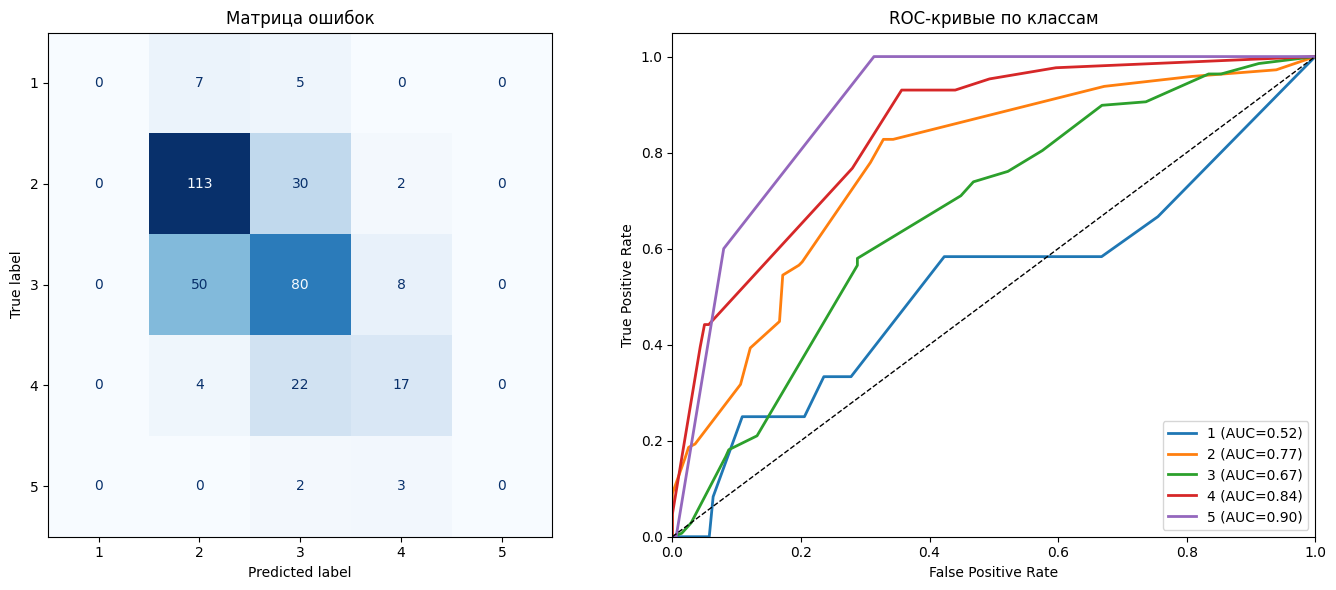

In [473]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42, max_depth=5)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)

decision_tree_result = get_metrics(y_test, y_pred, y_prob, class_names=['1', '2', '3', '4', '5'])